# Wizualizacja własności wielomianów Hermite'a
Konrad Słotta 277442

### Definicja
Wielomiany Hermite'a to wielomiany o współczynnikach rzeczywistych, będące rozwiązaniem równania rekurencyjnego
$$
H_{n+1}(x) = 2xH_n(x) - 2nH_{n-1}(x),
$$
przy warunkach początkowych $H_0(x) = 1$, $H_1(x) = 2x$.

### Własności wielomianów Hermite'a
- $H_n(x)$ jest wielomianem $n$-tego stopnia.
- $\displaystyle H_{2n}(0) = (-1)^{n}\frac{(2n)!}{n!}$,
- $\displaystyle \frac{\text{d}H_n(x)}{\text{d}x} = 2nH_{n-1}(x),$
- $\displaystyle H_n(-x) = (-1)^nH_n(x)$, czyli dla $n$ parzystego $H_n(x)$ jest funkcją parzystą a dla $n$ nieparzystego $H_n(x)$ jest funkcją nieparzystą.
- $\displaystyle \int_{-\infty}^{\infty}H_n(x)H_m(x)e^{-x^2}\text{d}x = \sqrt{\pi}2^nn!\delta_{nm}$, czyli wielomiany Hermite’a tworzą układ wielomianów ortogonalnych z funkcją wagową $e^{-x^2}$.

Źródło: https://pl.wikipedia.org/wiki/Wielomiany_Hermite%E2%80%99a

### Implementacja funkcji tworzącej wielomiany Hermite'a

In [1]:
using SpecialFunctions
using Plots
using LaTeXStrings

In [2]:
function hermite(n, x)
    if n == 0
        return 1
    elseif n == 1
        return 2x
    else
        Hn_1 = 2x
        Hn_2 = 1
        for k in 1:n-1
            Hn = 2x * Hn_1 - 2k*Hn_2
            Hn_2 = Hn_1
            Hn_1 = Hn
        end
        return Hn_1
    end
end

hermite (generic function with 1 method)

### Wizualizacja wielomianów w zależności od parametru n

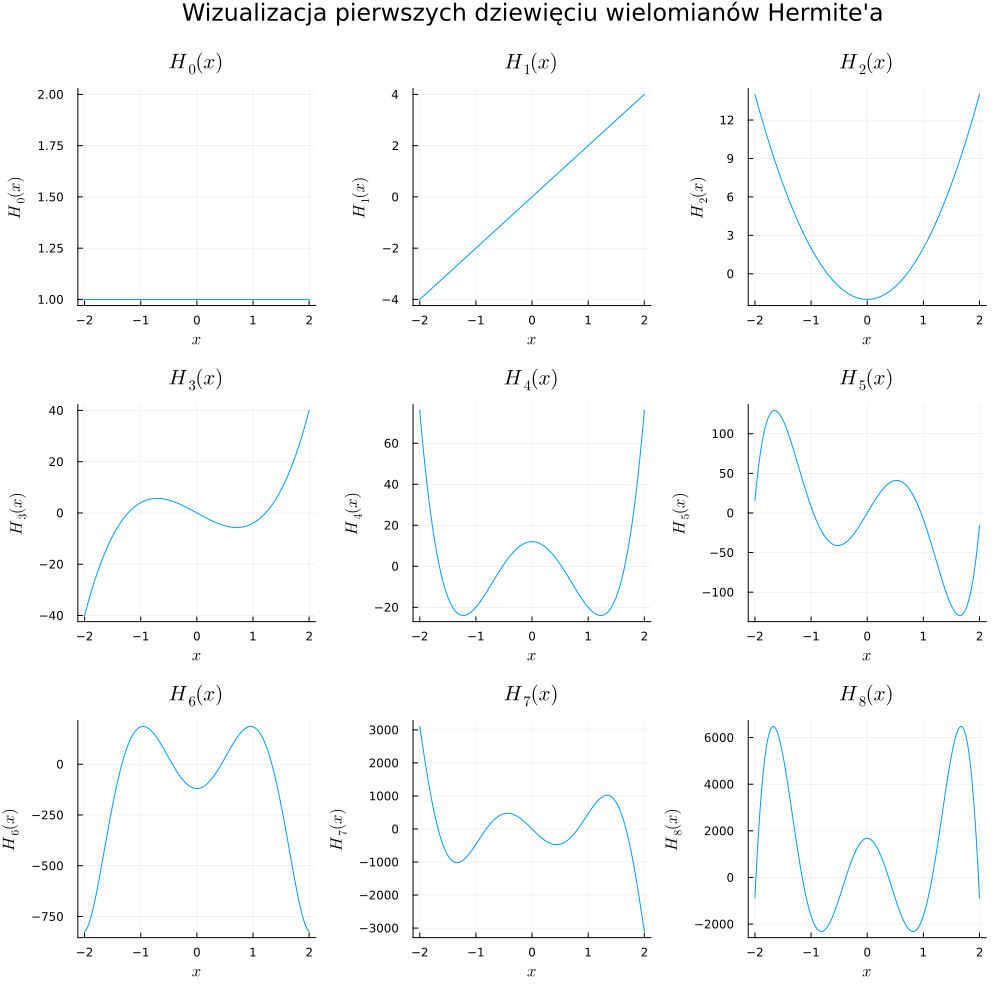

In [13]:
xs = range(-2, 2, length=500)

plots = [
    plot(xs, hermite.(n, xs), title=L"H_%$n(x)", xlabel = L"x", ylabel = L"H_%$n(x)", label = "")
    for n in 0:8
]

plot(plots..., layout=(3,3), size=(1000, 1000), plot_title = "Wizualizacja pierwszych dziewięciu wielomianów Hermite'a")

Na powyższych wykresach widać, że w zależności od parametru $n$ zmienia się parzystość funkcji. Dla $n$ nieparzystych funkcja $H_n(x)$ jest nieparzysta, a dla $n$ parzystych $H_n(x)$ jest parzysta. Dodatkowo przy większych $n$ funkcja $H_n(x)$ szybciej osiąga wartości bardzo duże oraz bardzo małe.

### Wizualizacja własności
$$
    H_{2n}(0) = (-1)^{n}\frac{(2n)!}{n!}
$$

In [26]:
function hermite_zero(n)
    return (-1)^(n/2) * factorial(big(n))/factorial(big(n/2))
end

hermite_zero (generic function with 1 method)

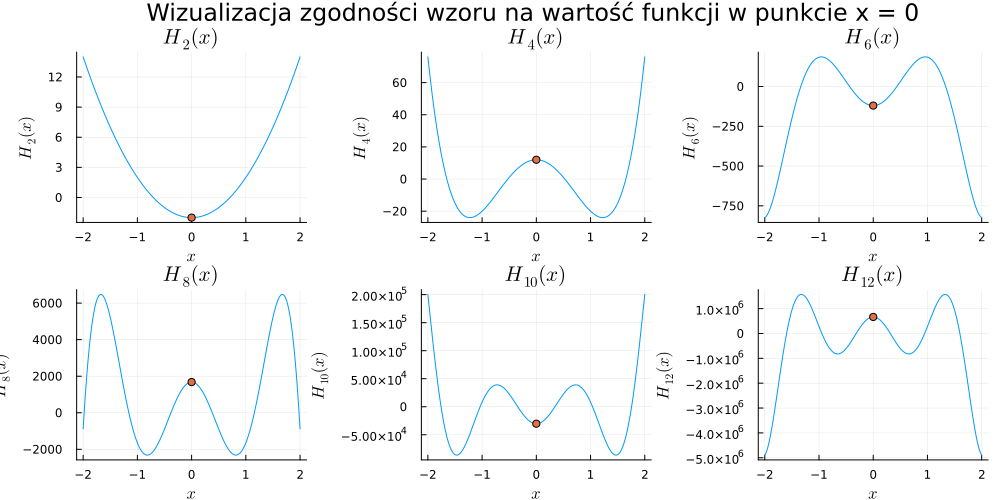

In [33]:
xs = range(-2, 2, length=500)

plots = [
    begin
        p = plot(xs, hermite.(n, xs), title=L"H_{%$n}(x)", xlabel = L"x", ylabel = L"H_{%$n}(x)", label = "")

        scatter!(p, [0], [hermite_zero(n)], label="")

        p
    end
    for n in 2:2:12
]

plot(plots..., layout=(2,3), size=(1000, 500), plot_title = "Wizualizacja zgodności wzoru na wartość funkcji w punkcie x = 0")